In [17]:
pip install mlxtend xgboost imblearn progressbar scanpy

Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
os.chdir("C:\\Users\\Le Tian\\Desktop\\Ensemble modeling\\comp-401")
os.getcwd()

'C:\\Users\\Le Tian\\Desktop\\Ensemble modeling\\comp-401'

In [21]:
import pandas as pd
from multi_omics_integration.func import *
from multi_omics_integration.classification_pipeline import *
from multi_omics_integration.processing import *
from multi_omics_integration.evaluation import *
import json
import warnings
from pandas.errors import SettingWithCopyWarning
from sklearn.exceptions import ConvergenceWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=ConvergenceWarning)
warnings.filterwarnings('ignore', 'Solver terminated early.*')

# KIPAN Subtyping

In [23]:
datasets = {
            'rna': '../Datasets/kipan/subtyping/RNASeq.csv',
            'cnv': '../Datasets/kipan/subtyping/CNV.csv',
            'rppa': '../Datasets/kipan/subtyping/RPPA.csv',
}

labels = '../Datasets/kipan/subtyping/Clinical.csv'

In [25]:
subtypes = pd.read_csv(labels, index_col=0)
data = {}

for modality in datasets:
    data[modality] = pd.read_csv(datasets[modality], index_col=0)
    print(modality, data[modality].shape)

rna (736, 20190)
cnv (736, 24776)
rppa (736, 202)


In [26]:
import scanpy as sc
from scanpy.pp import highly_variable_genes
import anndata as an

In [45]:
adata = {}

for modality in datasets:
  data[modality] = data[modality].dropna(axis=1)
  adata[modality] = an.AnnData(data[modality])

In [47]:
sc.pp.highly_variable_genes(adata['rna'])

In [48]:
sc.pp.highly_variable_genes(adata['cnv'])

c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:218: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


In [50]:
sc.pp.highly_variable_genes(adata['rppa'])

c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:218: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


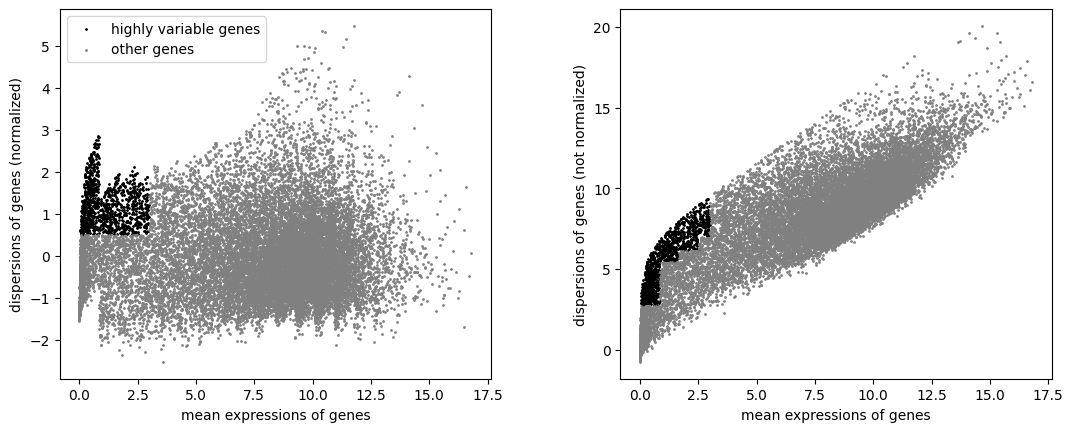

In [53]:
sc.pl.highly_variable_genes(adata['rna'])

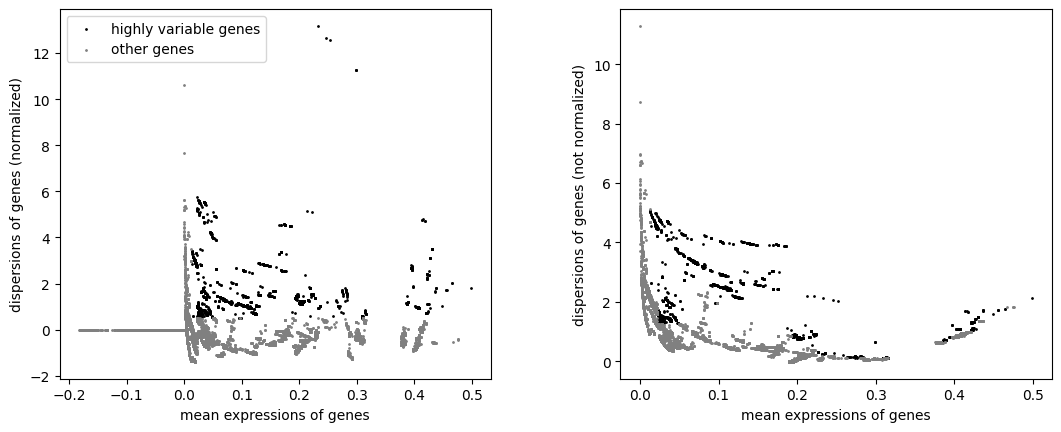

In [55]:
sc.pl.highly_variable_genes(adata['cnv'])

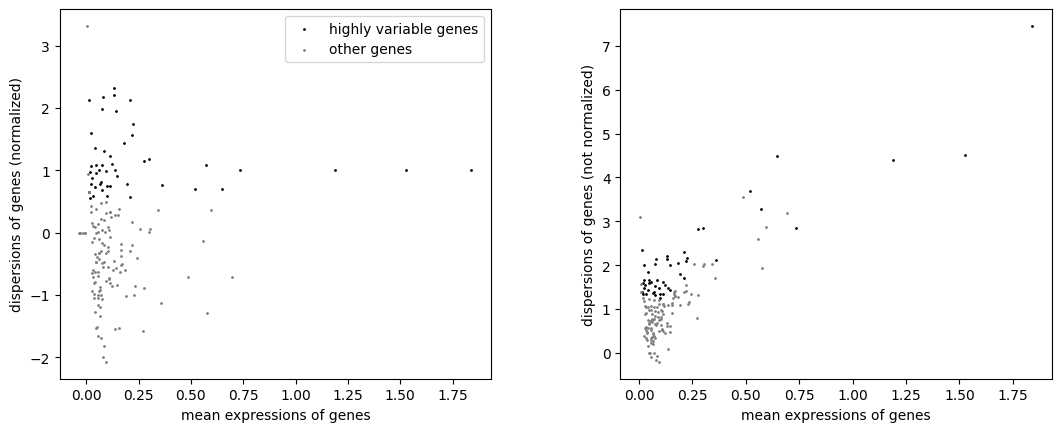

In [57]:
sc.pl.highly_variable_genes(adata['rppa'])

In [59]:
adata_new = {}

for modality in datasets:
  adata_new[modality] = adata[modality][:, adata[modality].var.highly_variable]
  sc.pp.scale(adata_new[modality], max_value=10)

c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [61]:
adata_new

{'rna': AnnData object with n_obs × n_vars = 736 × 1031
     var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'hvg',
 'cnv': AnnData object with n_obs × n_vars = 736 × 2986
     var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'hvg',
 'rppa': AnnData object with n_obs × n_vars = 736 × 48
     var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'hvg'}

In [63]:
import pandas as pd

X = {}

# Convert numpy array to DataFrame
for modality in adata_new:
    X[modality] = adata_new[modality].to_df()
    print(modality, X[modality].shape)

rna (736, 1031)
cnv (736, 2986)
rppa (736, 48)


In [65]:
subtypes['histological_type'].value_counts()

histological_type
kidneyclearcellrenalcarcinoma        467
kidneypapillaryrenalcellcarcinoma    206
kidneychromophobe                     63
Name: count, dtype: int64

In [67]:
enc = LabelEncoder()
y = enc.fit_transform(subtypes['histological_type'])
enc.inverse_transform([0, 1, 2])

array(['kidneychromophobe', 'kidneyclearcellrenalcarcinoma',
       'kidneypapillaryrenalcellcarcinoma'], dtype=object)

In [69]:
new_subtypes = subtypes

In [71]:
new_subtypes['histological_type_enc'] = enc.fit_transform(subtypes['histological_type'])

In [73]:
new_subtypes

,histological_type,pathologic_stage,survival_time,status,histological_type_enc
SubjectID,,,,,
TCGA.KL.8324,kidneychromophobe,stageii,4676.0,0.0,0
TCGA.KL.8325,kidneychromophobe,stageii,725.0,1.0,0
TCGA.KL.8326,kidneychromophobe,stageiii,3322.0,0.0,0
TCGA.KL.8327,kidneychromophobe,stagei,4169.0,0.0,0
TCGA.KL.8328,kidneychromophobe,stageii,3127.0,0.0,0
...,...,...,...,...,...
TCGA.Y8.A897,kidneypapillaryrenalcellcarcinoma,stagei,549.0,0.0,2
TCGA.Y8.A8RY,kidneypapillaryrenalcellcarcinoma,stagei,769.0,0.0,2
TCGA.Y8.A8RZ,kidneypapillaryrenalcellcarcinoma,stagei,205.0,0.0,2


In [75]:
new_subtypes['histological_type_enc'].to_csv('../Datasets/kipan/subtyping/Clinical_enc.csv')

In [79]:
import csv

filenames = {'rna': '../Datasets/kipan/subtyping/RNASeq_clean.csv', 'cnv': '../Datasets/kipan/subtyping/CNV_clean.csv', 'rppa': '../Datasets/kipan/subtyping/RPPA_clean.csv'}

for modality in filenames:
  X[modality].to_csv(filenames[modality])

# KIPAN Staging

In [81]:
datasets = {
            'rna': '../Datasets/kipan/staging/RNASeq.csv',
            'meth': '../Datasets/kipan/staging/Methylation.csv',
            'rppa': '../Datasets/kipan/staging/RPPA.csv',
}

labels = '../Datasets/kipan/staging/Clinical.csv'

In [83]:
stages = pd.read_csv(labels, index_col=0)
data = {}

for modality in datasets:
    data[modality] = pd.read_csv(datasets[modality], index_col=0)
    print(modality, data[modality].shape)

rna (558, 20190)
meth (558, 20116)
rppa (558, 202)


## Preprocessing

### Removing low-variance + null features

In [86]:
import scanpy as sc
from scanpy.pp import highly_variable_genes
import anndata as an

In [87]:
adata = {}

for modality in datasets:
  data[modality] = data[modality].dropna(axis=1)
  adata[modality] = an.AnnData(data[modality])

In [88]:
sc.pp.highly_variable_genes(adata['rna'])

In [89]:
sc.pp.highly_variable_genes(adata['meth'])

c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:218: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


In [90]:
sc.pp.highly_variable_genes(adata['rppa'])

c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:218: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


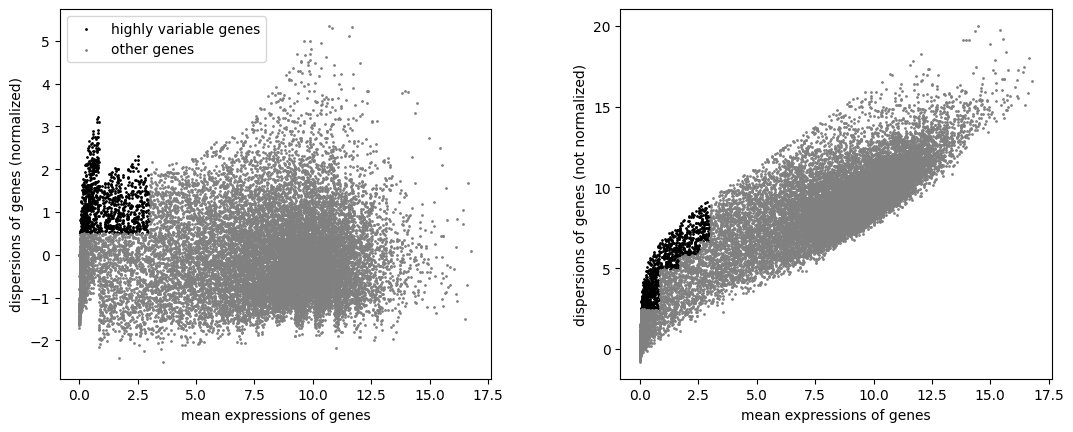

In [91]:
sc.pl.highly_variable_genes(adata['rna'])

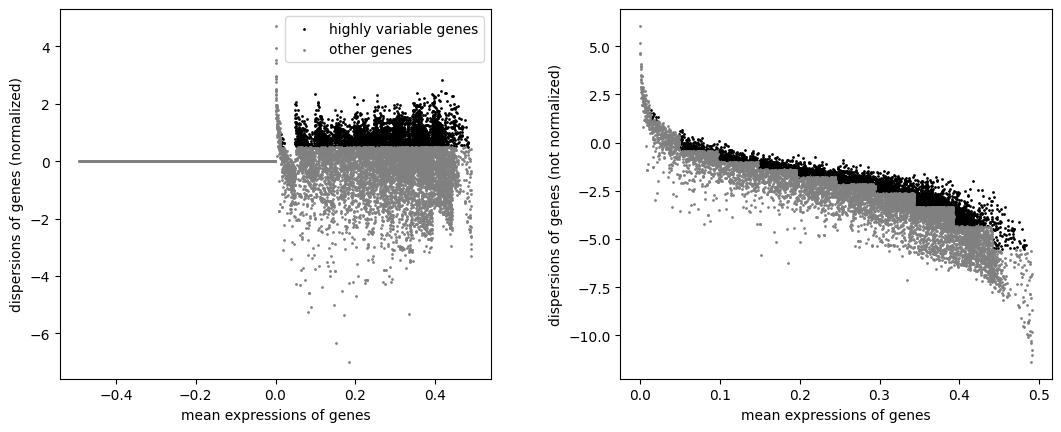

In [92]:
sc.pl.highly_variable_genes(adata['meth'])

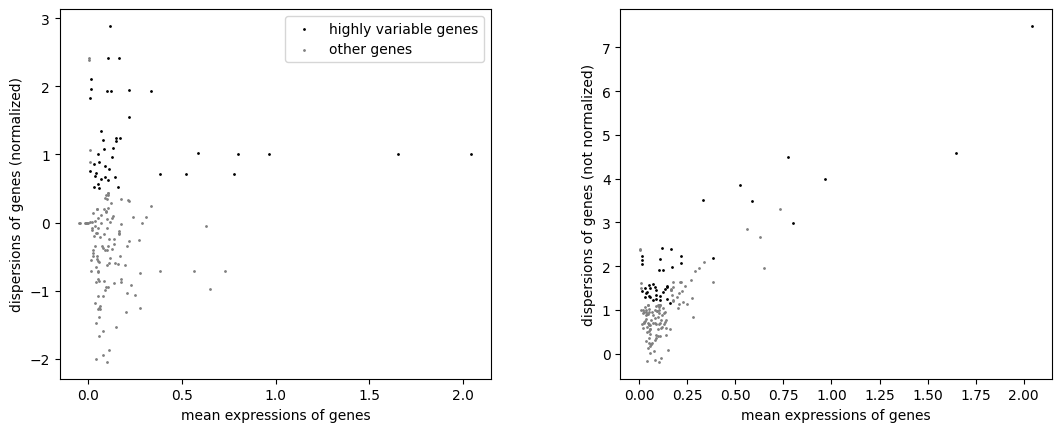

In [93]:
sc.pl.highly_variable_genes(adata['rppa'])

In [94]:
adata_new = {}

for modality in datasets:
  adata_new[modality] = adata[modality][:, adata[modality].var.highly_variable]
  sc.pp.scale(adata_new[modality], max_value=10)

c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [95]:
adata_new

{'rna': AnnData object with n_obs × n_vars = 558 × 1041
     var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'hvg',
 'meth': AnnData object with n_obs × n_vars = 558 × 3179
     var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'hvg',
 'rppa': AnnData object with n_obs × n_vars = 558 × 43
     var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'hvg'}

In [99]:
import pandas as pd

X = {}

# Convert numpy array to DataFrame
for modality in adata_new:
    X[modality] = adata_new[modality].to_df()
    print(modality, X[modality].shape)

rna (558, 1041)
meth (558, 3179)
rppa (558, 43)


In [111]:
stages = pd.read_csv(labels, index_col=0)
stages['pathologic_stage'].value_counts()

pathologic_stage
stagei      280
stageiii    129
stageiv      79
stageii      70
Name: count, dtype: int64

In [113]:
enc = LabelEncoder()
y = enc.fit_transform(stages['pathologic_stage'])
enc.inverse_transform([0, 1, 2, 3])

array(['stagei', 'stageii', 'stageiii', 'stageiv'], dtype=object)

In [115]:
# Assuming your array is named 'arr'
y = np.where(np.logical_or(y == 0, y == 1), 0, 1)

In [117]:
unique, counts = np.unique(y, return_counts=True)
np.asarray((unique, counts)).T

array([[  0, 350],
       [  1, 208]], dtype=int64)

In [119]:
import csv

filenames = {'rna': '../Datasets/kipan/staging/RNASeq_clean.csv', 'meth': '../Datasets/kipan/staging/meth_clean.csv', 'rppa': '../Datasets/kipan/staging/RPPA_clean.csv'}

for modality in filenames:
  X[modality].to_csv(filenames[modality])

In [121]:
new_stages = stages
new_stages['stage_enc'] = enc.fit_transform(stages['pathologic_stage'])
new_stages['stage_enc'] = np.where(np.logical_or(new_stages['stage_enc'] == 0, new_stages['stage_enc'] == 1), 0, 1)

In [123]:
new_stages['stage_enc'].value_counts()

stage_enc
0    350
1    208
Name: count, dtype: int64

In [125]:
new_stages['stage_enc'].to_csv('../Datasets/kipan/staging/Clinical_enc.csv')

# BRCA

In [150]:
datasets = {
            'rna': '../Datasets/breast/RNASeq.csv',
            'mirna': '../Datasets/breast/miRNASeq.csv',
            'meth': '../Datasets/breast/Methylation.csv',
}

labels = '../Datasets/breast/Clinical.csv'

In [152]:
subtypes = pd.read_csv(labels, index_col=0)
data = {}

for modality in datasets:
    data[modality] = pd.read_csv(datasets[modality], index_col=0)
    print(modality, data[modality].shape)

rna (430, 20155)
mirna (430, 823)
meth (430, 20106)


In [153]:
adata = {}

for modality in datasets:
  data[modality] = data[modality].dropna(axis=1)
  adata[modality] = an.AnnData(data[modality])

In [154]:
sc.pp.highly_variable_genes(adata['rna'])

In [155]:
sc.pp.highly_variable_genes(adata['mirna'])

In [156]:
sc.pp.highly_variable_genes(adata['meth'])

c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:218: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


In [157]:
adata_new = {}

for modality in datasets:
  adata_new[modality] = adata[modality][:, adata[modality].var.highly_variable]
  sc.pp.scale(adata_new[modality], max_value=10)

c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
c:\Users\Le Tian\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [158]:
adata_new

{'rna': AnnData object with n_obs × n_vars = 430 × 992
     var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'hvg',
 'mirna': AnnData object with n_obs × n_vars = 430 × 126
     var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'hvg',
 'meth': AnnData object with n_obs × n_vars = 430 × 2974
     var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'hvg'}

In [159]:
import pandas as pd

X = {}

# Convert numpy array to DataFrame
for modality in adata_new:
    X[modality] = adata_new[modality].to_df()
    print(modality, X[modality].shape)

rna (430, 992)
mirna (430, 126)
meth (430, 2974)


In [160]:
subtypes['PAM50'].value_counts()

PAM50
LumA     229
LumB     100
Basal     71
Her2      30
Name: count, dtype: int64

In [161]:
enc = LabelEncoder()
y = enc.fit_transform(subtypes['PAM50'])
enc.inverse_transform([0, 1, 2])

array(['Basal', 'Her2', 'LumA'], dtype=object)

In [172]:
import csv

filenames = {'rna': '../Datasets/breast/RNASeq_clean.csv', 'mirna': '../Datasets/breast/miRNASeq_clean.csv', 'meth': '../Datasets/breast/Methylation_clean.csv'}

for modality in filenames:
  X[modality].to_csv(filenames[modality])

In [173]:
new_subtypes = subtypes
new_subtypes['PAM50'] = enc.fit_transform(subtypes['PAM50'])

In [174]:
new_subtypes

,PAM50,survival_time,status
SubjectID,,,
TCGA.A1.A0SF,2,1463.0,0.0
TCGA.A1.A0SI,3,635.0,0.0
TCGA.A1.A0SN,3,1196.0,0.0
TCGA.A1.A0SQ,2,554.0,0.0
TCGA.A2.A0CK,2,4159.0,0.0
...,...,...,...
TCGA.LQ.A4E4,2,849.0,0.0
TCGA.OL.A66H,2,812.0,0.0
TCGA.OL.A66I,0,714.0,0.0


In [178]:
new_subtypes['PAM50'].to_csv('../Datasets/breast/Clinical_enc.csv')